# T2S Pipeline

Thin orchestrator: every cell just calls into a decoupled module and names its output via `results.py`. No modeling/training logic lives in this notebook — that all lives in the `.py` files, where it's unit-tested (`tests/`).

Expert policy pretraining is **skipped** — assumed already done, checkpoints under `train_res/expertPolicy/`.

In [2]:
import sys, os
sys.path.insert(0, os.getcwd())

import config
import results
config.ensure_dirs()
print('root:', config.ROOT_DIR)

root: d:\!DUKE\2026_Fall\Independent_Research\grl-t2s


## 1. Expert Policy Pretraining

Checkpoints live in `config.EXPERT_POLICY_DIR` = `train_res/expertPolicy/<config.EXPERT_RUN_NAME>/`, alongside `eval_history.json`. Toggle `RUN_EXPERT_TRAINING = False` (default) to just verify an existing run is there; `True` trains into that same folder.

In [3]:
import expert_train, glob

RUN_EXPERT_TRAINING = False   # set True to actually train into config.EXPERT_POLICY_DIR

expert_run_dir = config.EXPERT_POLICY_DIR   # train_res/expertPolicy/<EXPERT_RUN_NAME>/
os.makedirs(expert_run_dir, exist_ok=True)

if RUN_EXPERT_TRAINING:
    results.new_run_dir('expert_policy', config.EXPERT_RUN_NAME, meta={'task_name': config.TASK_NAME})
    model, expert_history = expert_train.train_expert_policy(expert_run_dir)
    print('trained expert, final success rate:', expert_history[-1] if expert_history else None)
else:
    ckpts = glob.glob(os.path.join(expert_run_dir, f'{config.TASK_SLUG}_*.zip'))
    assert ckpts, (f'no expert checkpoints found in {expert_run_dir} for task {config.TASK_NAME} — '
                    'place them there (see chat for the rename command) or set RUN_EXPERT_TRAINING=True')
    print(f'reusing {len(ckpts)} expert checkpoints from {expert_run_dir}')

reusing 8 expert checkpoints from d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\expertPolicy\peg-insert


## 2. T2S Data Collection

In [4]:
import data_collection
from env_utils import ensure_fixed_task

ensure_fixed_task()

DATA_RUN_NAME = 'v7'
data_run_dir = results.new_run_dir('data_collection', DATA_RUN_NAME,
                                     meta={'notes': 'coupling-based stage detection'})

plan = data_collection.default_collection_plan(
    expert_policy_dir=expert_run_dir,
    checkpoints=['peg_insert_side_v3_100000.zip', 'peg_insert_side_v3_400000.zip', 'peg_insert_side_v3_final.zip'],
    include_noise_variants=True,
)
summary = data_collection.collect_dataset(
    data_run_dir, plan=plan, expert_policy_dir=expert_run_dir,
    failure_checkpoint='peg_insert_side_v3_100000.zip',   # <- explicit, no guessing
    failure_noise_candidates=(0.4, 0.6, 0.8, 1.0, 1.5, 2.0, 3.0),
    failure_max_success_rate=0.4,
)
print(summary)

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


forced failure source: peg_insert_side_v3_100000.zip @ noise=0.4 (measured success rate 0% over 5 probes)
{'total_rows': 111000, 'total_episodes': 222, 'obs_dim': 39, 'successful_episodes': 128, 'failed_episodes': 94, 'censor_label': 300.0, 'stage_fractions': {0: 1.0, 1: 0.0, 2: 0.0}, 'sources': ['peg_insert_side_v3_100000.zip_n0.0', 'peg_insert_side_v3_100000.zip_n0.15', 'peg_insert_side_v3_100000.zip_n0.4', 'peg_insert_side_v3_400000.zip_n0.0', 'peg_insert_side_v3_400000.zip_n0.15', 'peg_insert_side_v3_400000.zip_n0.4', 'peg_insert_side_v3_final.zip_n0.0', 'peg_insert_side_v3_final.zip_n0.15', 'peg_insert_side_v3_final.zip_n0.4'], 'forced_failure_source': {'checkpoint': 'peg_insert_side_v3_100000.zip', 'noise': 0.4, 'measured_success_rate': 0.0}}


## 3. T2S Model Training (MC / TD(0) / TD(&lambda;))

In [5]:
import t2s_train

T2S_RUN_NAME = 'v1'
t2s_run_dir = results.new_run_dir('t2s_model', T2S_RUN_NAME,
                                    meta={'data_run': DATA_RUN_NAME})
dataset_path = os.path.join(data_run_dir, 'dataset.npz')

models, histories, summary_rows = t2s_train.run_all_combos(
    t2s_run_dir, dataset_path, seeds=(0,))
for row in summary_rows:
    print(row['combo'], 'mean val MSE:', round(row['mean_val_mse'], 1))

mc_succ mean val MSE: 7.6
mc_all mean val MSE: 66.9
td0_succ mean val MSE: 21.1
td0_all mean val MSE: 35137.6
tdlambda_succ mean val MSE: 7.1
tdlambda_all mean val MSE: 157.2


## 4. T2S Model Analysis (held-out policies — never in training data)

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


combo                      mae          rmse     pearson_r  spearman_rhomax_wrong_direction
-------------------------------------------------------------------------------------------
mc_succ                 9.8088       14.8061        0.9446        0.9447        6.4703
mc_all                  9.5247       18.0594        0.8998        0.9396        9.7316
td0_succ                5.3007        7.9864        0.9905        0.9827        1.4558
td0_all                 4.4700        5.8115        0.9786        0.9873        0.0775
tdlambda_succ           7.5759       11.5298        0.9752        0.9574        3.9338
tdlambda_all            8.2707       19.0776        0.9006        0.9855        1.8698


d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")
d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")
d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")
d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\t2s_eval.py:187: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(combos, rotation=45, ha="right")


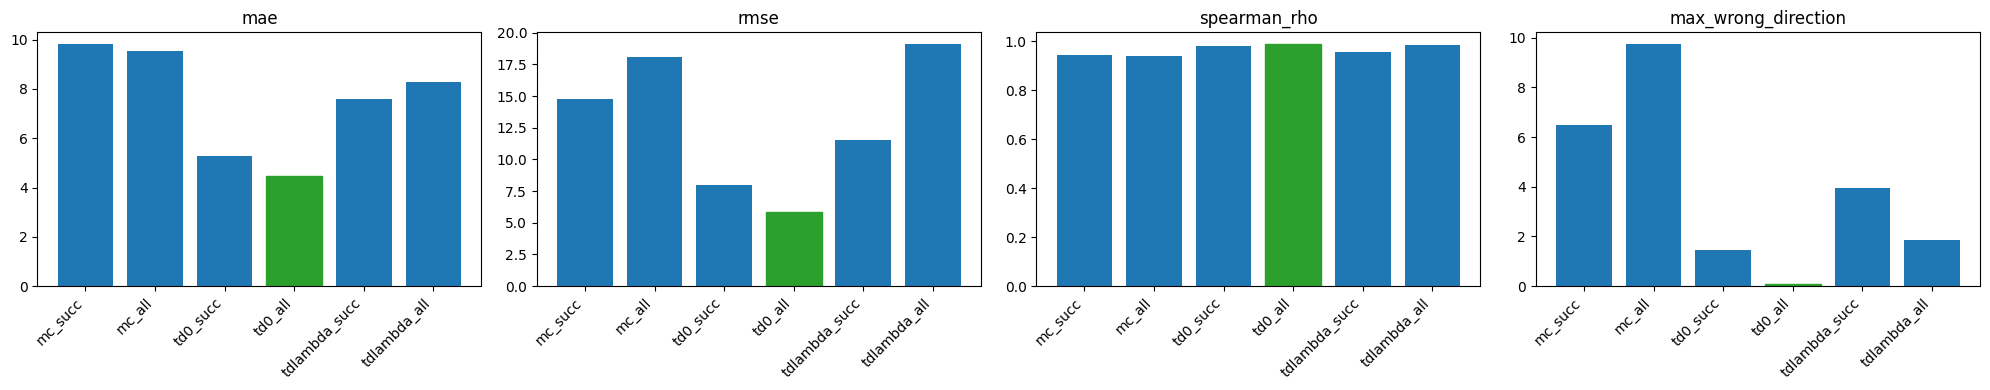

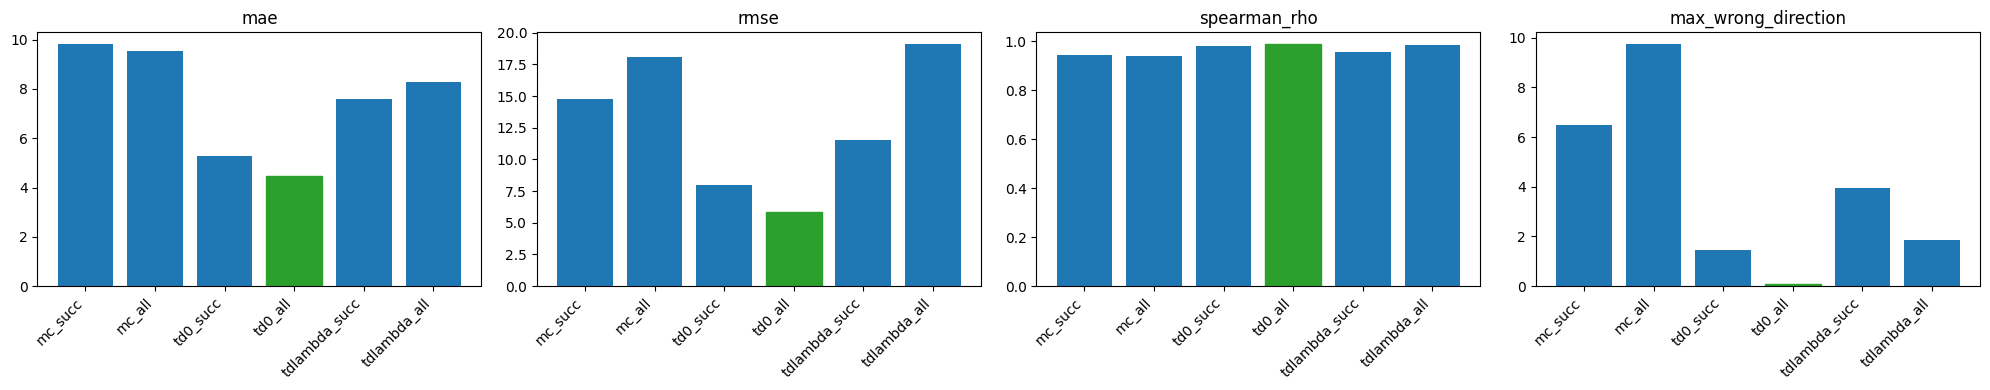

In [8]:
import json
import t2s_predict, t2s_eval
from stable_baselines3 import SAC

EVAL_RUN_NAME = 'v1'
eval_run_dir = results.new_run_dir('t2s_eval', EVAL_RUN_NAME, meta={'t2s_run': T2S_RUN_NAME})

# TODO: point these at checkpoints that were genuinely never used in data_collection.default_collection_plan()
eval_success_pol = SAC.load('train_res/expertPolicy/peg-insert/peg_insert_side_v3_700000.zip')
eval_failure_pol = SAC.load('train_res/expertPolicy/peg-insert/peg_insert_side_v3_200000.zip')

reports = {}
for combo in summary_rows:
    method, condition = combo['combo'].rsplit('_', 1)
    predict_fn = t2s_predict.load_t2s_predictor(t2s_run_dir, method, condition, seed=combo['best_seed'])
    reports[combo['combo']] = t2s_eval.run_full_evaluation(predict_fn, eval_success_pol, eval_failure_pol)

with open(os.path.join(eval_run_dir, 'eval_report.json'), 'w') as f:
    json.dump(reports, f, indent=2)
print(t2s_eval.format_report_table(reports))

t2s_eval.plot_combo_comparison(reports, save_path=os.path.join(eval_run_dir, 'combo_comparison.png'))

## 4b. Resume point — run this after a kernel restart

Rebuilds everything Section 5 needs (`t2s_run_dir`, `summary_rows`, `reports`) from files already on disk, so you can jump straight to downstream RL without re-running Stages 1-4. Run the first cell of the notebook (imports) first, then this, then Section 5.

In [4]:
import json, os
import t2s_predict, t2s_eval, t2s_io

# --- point these at the runs you already completed ---
T2S_RUN_NAME  = 'v1'
EVAL_RUN_NAME = 'v1'

t2s_run_dir  = results.get_run_dir('t2s_model', T2S_RUN_NAME)
eval_run_dir = results.get_run_dir('t2s_eval', EVAL_RUN_NAME)

# rebuild summary_rows from the Stage 3 manifest (not recomputed — just read back)
manifest = t2s_io.load_manifest(t2s_run_dir)
summary_rows = [
    dict(combo=combo, mean_val_mse=info['mean_val_mse'], std_val_mse=info['std_val_mse'],
         seeds_val_mse=info['per_seed_val_mse'],
         mean_val_mse_succ_only=info['mean_val_mse_succ_only'],
         best_seed=info['best_seed'])
    for combo, info in manifest['combos'].items()
]

# rebuild reports from the Stage 4 eval report
with open(os.path.join(eval_run_dir, 'eval_report.json')) as f:
    reports = json.load(f)

print(f'resumed: {len(summary_rows)} combos from {t2s_run_dir}')
print(f'         {len(reports)} eval reports from {eval_run_dir}')
print()
print(t2s_eval.format_report_table(reports))

resumed: 6 combos from d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\t2s_model\v1
         6 eval reports from d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\t2s_eval\v1

combo                      mae          rmse     pearson_r  spearman_rhomax_wrong_direction
-------------------------------------------------------------------------------------------
mc_succ                 9.8088       14.8061        0.9446        0.9447        6.4703
mc_all                  9.5247       18.0594        0.8998        0.9396        9.7316
td0_succ                5.3007        7.9864        0.9905        0.9827        1.4558
td0_all                 4.4700        5.8115        0.9786        0.9873        0.0775
tdlambda_succ           7.5759       11.5298        0.9752        0.9574        3.9338
tdlambda_all            8.2707       19.0776        0.9006        0.9855        1.8698


## 5. Downstream RL Training (SAC against the frozen T2S reward)

Choose the lowest error one to train

In [5]:
import policy_train

# Select by Stage 4's held-out-POLICY generalization report (MAE on genuinely
# unseen behavior), NOT Stage 3's training-time val MSE (mean_val_mse in
# summary_rows) — the two can and do disagree (see chat: mc_succ won on val
# MSE but td0_succ generalized better on held-out policies).
SELECTION_METRIC = 'mae'   # or 'rmse' / swap sign and use 'spearman_rho'/'pearson_r' for a correlation-based pick

scored = {
    combo: r['success_scenario_summary'][SELECTION_METRIC]
    for combo, r in reports.items()
    if 'success_scenario_summary' in r and SELECTION_METRIC in r['success_scenario_summary']
}
assert scored, 'no combo has a usable success_scenario_summary — check Section 4 ran against real held-out policies'
CHOSEN_COMBO = min(scored, key=scored.get)
print('Stage 4 ranking (lower is better) by', SELECTION_METRIC + ':')
for combo, v in sorted(scored.items(), key=lambda kv: kv[1]):
    print(f'  {combo:14s} {v:.3f}')
print('chosen:', CHOSEN_COMBO)



Stage 4 ranking (lower is better) by mae:
  td0_all        4.470
  td0_succ       5.301
  tdlambda_succ  7.576
  tdlambda_all   8.271
  mc_all         9.525
  mc_succ        9.809
chosen: td0_all


In [6]:
method, condition = CHOSEN_COMBO.rsplit('_', 1)
best_seed = next(r['best_seed'] for r in summary_rows if r['combo'] == CHOSEN_COMBO)
predict_fn = t2s_predict.load_t2s_predictor(t2s_run_dir, method, condition, seed=best_seed)

POLICY_RUN_NAME = f"t2s_{CHOSEN_COMBO}_absolute_v1"
policy_run_dir = results.new_run_dir('policy', POLICY_RUN_NAME,
                                       meta={'t2s_run': T2S_RUN_NAME, 'combo': CHOSEN_COMBO,
                                             'selected_by': f'stage4_{SELECTION_METRIC}'})

model, history = policy_train.train_policy(policy_run_dir, predict_fn, reward_mode='absolute',
                                             total_timesteps=1_000_000)
print('final success rate:', history[-1] if history else 'no evals recorded')

d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:34: UserWarning: WARN: A Box observation space maximum and minimum values are equal.
  logger.warn("A Box observation space maximum and minimum values are equal.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")
d:\Miniconda3\envs\duke_rob\lib\site-packages\gymnasium\utils\passive_env_checker.py:157: UserWarning: WARN: The obs returned by the `step()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


[eval @ 10002] success_rate=0.00 mean_t2s=None
[eval @ 20004] success_rate=0.00 mean_t2s=None
[eval @ 30000] success_rate=0.00 mean_t2s=None
[eval @ 40002] success_rate=0.00 mean_t2s=None
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\t2s_td0_all_absolute_v1\policy_50004.zip
[eval @ 50004] success_rate=0.00 mean_t2s=None
[eval @ 60000] success_rate=0.00 mean_t2s=None
[eval @ 70002] success_rate=0.00 mean_t2s=None
[eval @ 80004] success_rate=0.00 mean_t2s=None
[eval @ 90000] success_rate=0.00 mean_t2s=None
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\t2s_td0_all_absolute_v1\policy_100002.zip
[eval @ 100002] success_rate=0.00 mean_t2s=None
[eval @ 110004] success_rate=0.00 mean_t2s=None
[eval @ 120000] success_rate=0.00 mean_t2s=None
[eval @ 130002] success_rate=0.00 mean_t2s=None
[eval @ 140004] success_rate=0.00 mean_t2s=None
[ckpt] saved d:\!DUKE\2026_Fall\Independent_Research\grl-t2s\train_res\policy\t2s_td0_all_absolute